In [1]:
import numpy as np
import matplotlib.pyplot as plt
from functools import partial

rng = np.random.default_rng(42)


# ── dataset setting ───────────────────────────────────────────────────────────
def make_samples(means, std, n_per_mode):
    # vstack: vertical stack - 수직으로 쌓음
    return np.vstack([mu + rng.standard_normal((n_per_mode, 2)) * std for mu in means])


# Grid
g = np.linspace(-2, 2, 3)
grid_means = np.array([[x, y] for y in g for x in g])

# Moons
th = np.linspace(0, np.pi, 300)
moon_means = np.vstack(
    [
        np.column_stack([np.cos(th), np.sin(th)]),
        np.column_stack([1 - np.cos(th), 1 - np.sin(th) - 0.5]),
    ]
)

# Heart: reverse_test.ipynb의 정의를 참고용으로 유지
heart_t = np.linspace(0, 2 * np.pi, 20, endpoint=False)
heart_means = (
    np.column_stack(
        [
            16 * np.sin(heart_t) ** 3,
            13 * np.cos(heart_t) - 5 * np.cos(2 * heart_t) - 2 * np.cos(3 * heart_t) - np.cos(4 * heart_t),
        ]
    )
    / 10
)

# 이번 노트북에서 실제로 reverse 실험할 toydata
DATASET_CONFIGS = {
    "grid": {
        "means": grid_means,
        "std": 0.12,
        "n_per_mode": 150,
        "color": "#3498db",
        "title": "2D Grid",
    },
    "moons": {
        "means": moon_means,
        "std": 0.06,
        "n_per_mode": 1,
        "color": "#2ecc71",
        "title": "Two Moons",
    },
}

datasets = {
    name: make_samples(cfg["means"], std=cfg["std"], n_per_mode=cfg["n_per_mode"])
    for name, cfg in DATASET_CONFIGS.items()
}

# ── Noise schedule (연속 함수) ─────────────────────────────────────────────────
T = 500
_beta_start = 1e-4
_beta_end   = 0.02


def beta_fn(t):
    """t ∈ [0, T-1] 연속값 → beta (linear schedule)"""
    t = np.clip(t, 0, T - 1)
    return _beta_start + (_beta_end - _beta_start) * t / (T - 1)


def alpha_bar_fn(t):
    """t ∈ [0, T-1] 연속값 → ᾱ(t) = exp(-∫₀ᵗ β(s)ds)"""
    t = np.clip(t, 0, T - 1)
    a = _beta_start
    b = (_beta_end - _beta_start) / (T - 1)
    return np.exp(-(a * t + 0.5 * b * t**2))


def sigma2_fn(t):
    """t ∈ [0, T-1] 연속값 → σ²(t) = 1 - ᾱ(t)"""
    return 1.0 - alpha_bar_fn(t)


SAVE_STEPS = [0, 100, 200, 300, 400, 500]
t_arr = np.arange(T, -1, -1)


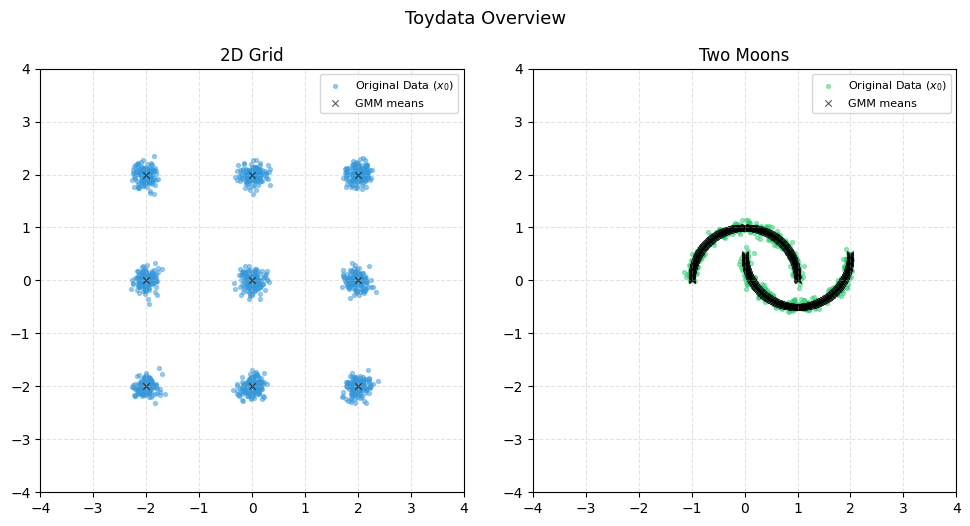

In [2]:
def plot_steps(traj, steps=None, order="asc", color="#3498db", title="", means=None):
    """스텝별 분포 시각화.

    order: "asc"  → t 오름차순 (forward, 0→T)
           "desc" → t 내림차순 (reverse, T→0)
    """
    if steps is None:
        steps = sorted(traj.keys())

    if order == "asc":
        steps = list(steps)
    elif order == "desc":
        steps = list(reversed(steps))
    else:
        raise ValueError(f"order must be 'asc' or 'desc', got {order!r}")

    ncols = int(len(steps) / 2)
    nrows = 2
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
    for ax, t in zip(axes.flatten(), steps):
        pts = traj.get(t)
        if pts is not None:
            ax.scatter(*pts.T, s=4, alpha=0.35, c=color)
        if means is not None:
            ax.scatter(*means.T, s=12, c="black", marker="x", linewidths=0.75, alpha=0.55)
        ax.set_xlim(-4, 4)
        ax.set_ylim(-4, 4)
        ax.set_aspect("equal")
        ax.set_title(f"t={t}")
    fig.suptitle(title, fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()


def plot_dataset_overview():
    fig, axes = plt.subplots(1, len(DATASET_CONFIGS), figsize=(5 * len(DATASET_CONFIGS), 5))
    axes = np.atleast_1d(axes)

    for ax, (name, cfg) in zip(axes, DATASET_CONFIGS.items()):
        pts = datasets[name]
        means = cfg["means"]
        ax.scatter(*pts.T, s=8, alpha=0.45, c=cfg["color"], label="Original Data ($x_0$)")
        ax.scatter(*means.T, s=22, c="black", marker="x", linewidths=0.8, alpha=0.65, label="GMM means")
        ax.set_xlim(-4, 4)
        ax.set_ylim(-4, 4)
        ax.set_aspect("equal")
        ax.grid(True, linestyle="--", alpha=0.35)
        ax.set_title(cfg["title"])
        ax.legend(loc="upper right", fontsize=8)

    fig.suptitle("Toydata Overview", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()


plot_dataset_overview()


## Forward VP-SDE

$$dx = -\frac{1}{2}\beta(t)\,x\,dt + \sqrt{\beta(t)}dW$$

$$\mathbf{x}_t = \sqrt{\bar{\alpha}_t}\,\mathbf{x}_0 + \sqrt{1-\bar{\alpha}_t}\,\boldsymbol{\epsilon}, \qquad \bar{\alpha}_t = \prod_{s=1}^t\alpha_s$$


In [3]:
# ── Forward SDE ───────────────────────────────────────────────────────────────
def forward_sde(x0):
    saved = {0: x0.copy()}
    x = x0.copy()
    for i in range(T):
        b = beta_fn(i)
        x = x * (1 - 0.5 * b) + np.sqrt(b) * rng.standard_normal(x.shape)
        saved[i + 1] = x.copy()
    return saved


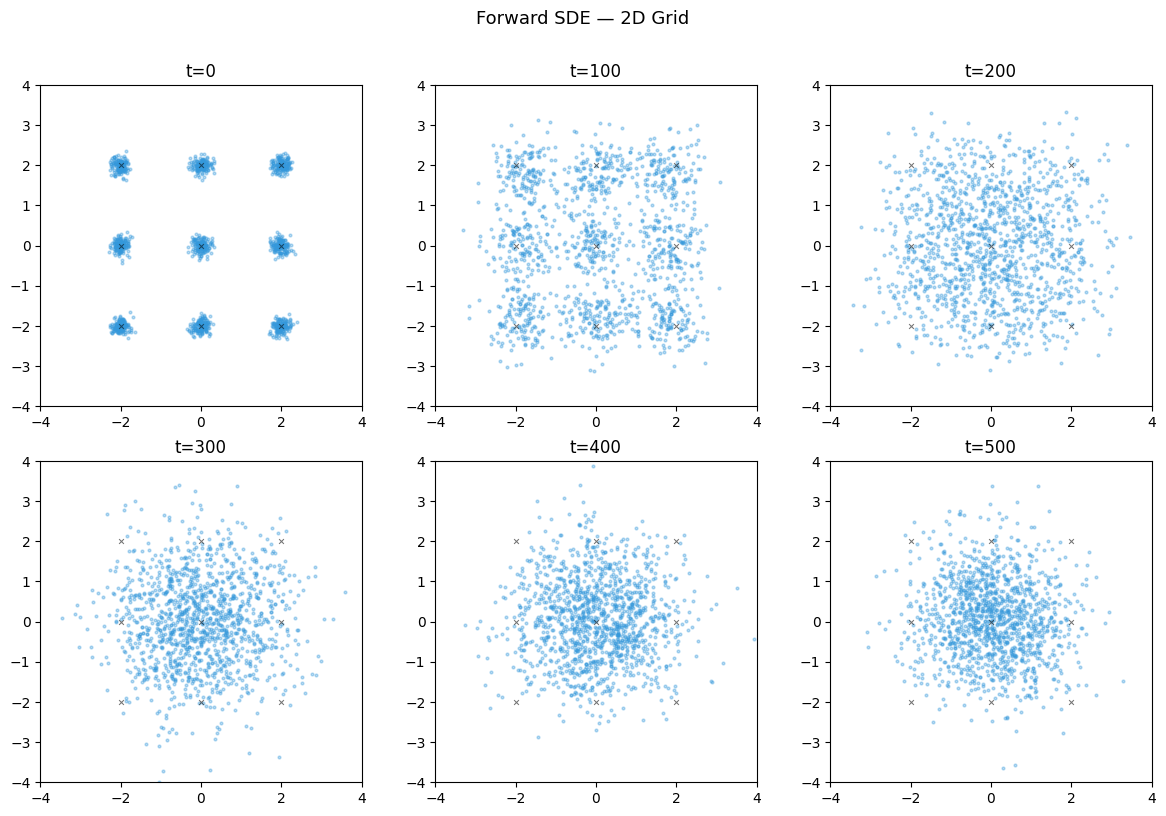

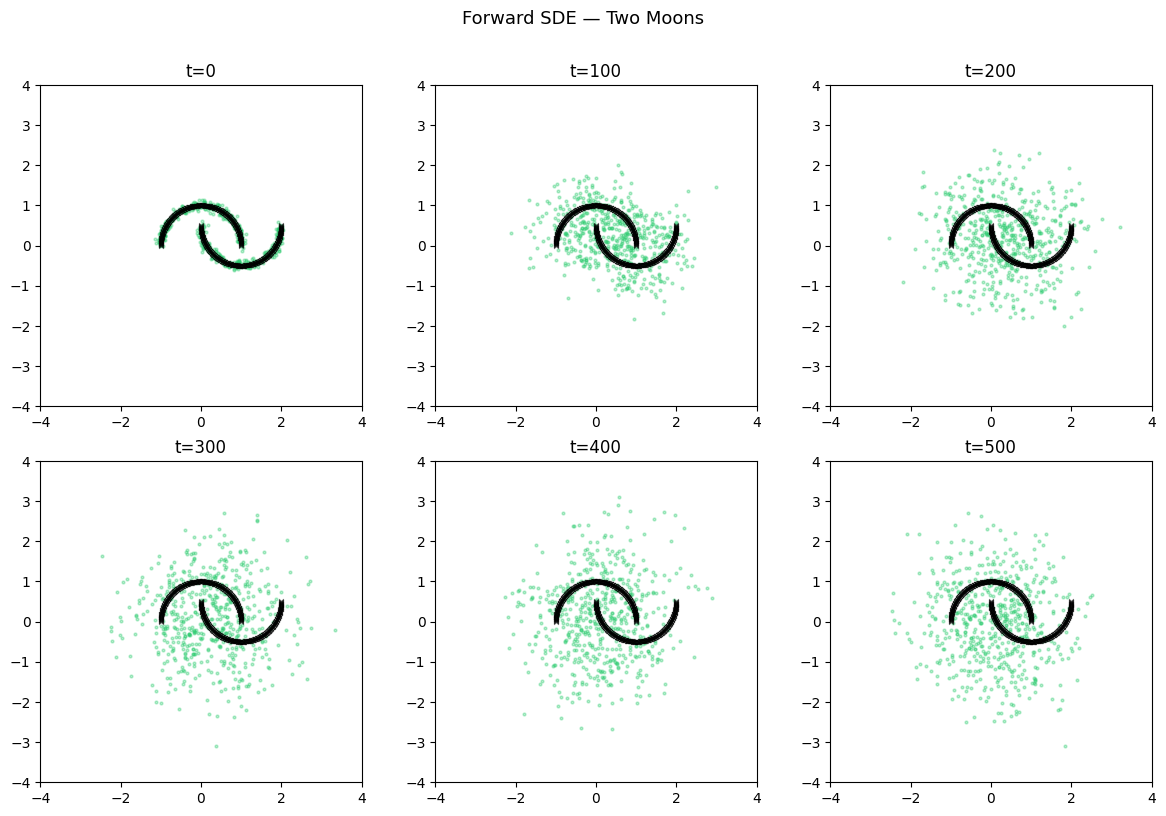

In [4]:
# ── Grid / Two Moons forward 확인 ────────────────────────────────────────────
fwd = {}
for name, x0 in datasets.items():
    fwd[name] = forward_sde(x0)

for name, cfg in DATASET_CONFIGS.items():
    plot_steps(
        fwd[name],
        steps=SAVE_STEPS,
        order="asc",
        color=cfg["color"],
        title=f"Forward SDE — {cfg['title']}",
        means=cfg["means"],
    )


## Reverse SDE (Anderson, 1982)

$$dx = \left[-\frac{1}{2}\beta(t)\,x - \beta(t)\,s(x,t)\right]dt + \sqrt{\beta(t)}\,d\bar{W}$$

## Euler-Maruyama (SDE Solver)
$$x_{t-1} = x_t + \beta_t\!\left(-\tfrac{1}{2}x_t - s(x_t,t)\right)\Delta t + \sqrt{\beta_t\Delta t}\,\epsilon$$


In [5]:
def reverse_em(x_T, t_arr, score_fn):
    traj = {int(t_arr[0]): x_T.copy()}
    x = x_T.copy()
    dt = -1
    for t in t_arr[1:]:
        b = beta_fn(t)
        s = score_fn(x, t)
        x = x + b * (-0.5 * x - s) * dt + np.sqrt(b) * rng.standard_normal(x.shape)
        traj[int(t)] = x.copy()
    return traj


## Probability Flow ODE (ODE Solver)

### 핵심 목표

**노이즈를 없애되, $p_t$의 시간 변화는 동일하게 유지**

SDE와 ODE는 서로 다른 방정식이지만, **Fokker-Planck 수준에서 일치하면 같은 $p_t$를 만들어냄.**

$$\frac{dx}{dt} = -\frac{1}{2}\beta(t)\,x - \frac{1}{2}\beta(t)\,s(x,t)$$


In [6]:
# Probability Flow ODE — 연속 t 사용
def PF_ODE(x, t, score_fn):
    b = beta_fn(t)
    s = score_fn(x, t)
    return -0.5 * b * x - 0.5 * b * s


### ODE Solvers

In [7]:
# Euler Method
def euler_method(f, r, t, **kwargs):
    h = t[1] - t[0]
    for i in range(1, len(t)):
        r[i] = r[i - 1] + h * f(r[i - 1], t[i - 1], **kwargs)

    return r


# Predictor Corrector Method(PCM)
def PCM(f, r, t, **kwargs):
    h = t[1] - t[0]
    for i in range(1, len(t)):
        p = r[i - 1] + h * f(r[i - 1], t[i - 1], **kwargs)
        r[i] = r[i - 1] + h / 2 * (f(r[i - 1], t[i - 1], **kwargs) + f(p, t[i - 1], **kwargs))

    return r


# Runge-Kutta Method(RK) - RK2
def RK2(f, r, t, **kwargs):
    h = t[1] - t[0]
    for i in range(len(t) - 1):
        k1 = h * f(r[i], t[i], **kwargs)
        k2 = h * f(r[i] + 0.5 * k1, t[i] + 0.5 * h, **kwargs)
        r[i + 1] = r[i] + k2
    return r


# RK4
def ODE_MV_RK4(f, r, t, **kwargs):
    h = t[1] - t[0]
    k = np.zeros((4, *r.shape[1:]), float)
    for i in range(len(t) - 1):
        k[0] = h * f(r[i], t[i], **kwargs)
        k[1] = h * f(r[i] + k[0] / 2, t[i] + h / 2, **kwargs)
        k[2] = h * f(r[i] + k[1] / 2, t[i] + h / 2, **kwargs)
        k[3] = h * f(r[i] + k[2], t[i] + h, **kwargs)
        r[i + 1] = r[i] + (k[0] + 2 * k[1] + 2 * k[2] + k[3]) / 6
    return r


In [8]:
def reverse_euler(x_T, t_arr, score_fn):
    r = np.empty((len(t_arr), *x_T.shape))
    r[0] = x_T

    r = euler_method(PF_ODE, r, t_arr, score_fn=score_fn)

    traj = {}
    for i, t in enumerate(t_arr):
        traj[int(t)] = r[i].copy()
    return traj


def reverse_PCM(x_T, t_arr, score_fn):
    r = np.empty((len(t_arr), *x_T.shape))
    r[0] = x_T

    r = PCM(PF_ODE, r, t_arr, score_fn=score_fn)

    traj = {}
    for i, t in enumerate(t_arr):
        traj[int(t)] = r[i].copy()
    return traj


def reverse_rk(x_T, t_arr, score_fn):
    r = np.empty((len(t_arr), *x_T.shape))
    r[0] = x_T

    r = RK2(PF_ODE, r, t_arr, score_fn=score_fn)

    traj = {}
    for i, t in enumerate(t_arr):
        traj[int(t)] = r[i].copy()
    return traj


def reverse_rk4(x_T, t_arr, score_fn):
    """Probability Flow ODE (deterministic), RK4 적분"""
    r = np.empty((len(t_arr), *x_T.shape))
    r[0] = x_T

    r = ODE_MV_RK4(PF_ODE, r, t_arr, score_fn=score_fn)

    traj = {}
    for i, t in enumerate(t_arr):
        traj[int(t)] = r[i].copy()
    return traj


---
## Case 0 — GMM Exact Score + EM vs ODE Solvers

VP-SDE의 marginal(주변분포, $x_t$)은 GMM(Gaussian Mixture Model)을 유지:
$$p_t(x) = \frac{1}{K}\sum_k \mathcal{N}\!\left(x;\;\sqrt{\bar\alpha_t}\mu_k,\;\bar\alpha_t\sigma_k^2 + \sigma_t^2\right)$$

Score는 각 모드 score의 **사후확률 가중 합**:
$$s(x,t) = \sum_k w_k(x,t)\cdot\left(-\frac{x-\sqrt{\bar\alpha_t}\mu_k}{\bar\alpha_t\sigma_k^2+\sigma_t^2}\right), \qquad w_k = \frac{p_t^{(k)}(x)}{\sum_j p_t^{(j)}(x)}$$

이것이 신경망 없이 구할 수 있는 **이론상 완벽한 score**입니다.


In [9]:
def gmm_score(x, t, means, var):
    ab = alpha_bar_fn(t)
    s2 = sigma2_fn(t)
    mu_t = np.sqrt(ab) * means   # K개 2D Gaussian 중심점 배열: (K,2)
    var_t = ab * var + s2        # scalar

    # N개의 각 점에서 K개의 중심점까지의 차이벡터
    # x: (N,2) -> (N,1,2)
    # mu_t: (K,2) -> (1,K,2)
    # diff: (N,1,2) - (1,K,2) = (N,K,2) - broadcasting
    diff = x[:, None, :] - mu_t[None, :, :]

    # Gaussian 밀도 구하는 과정
    # .sum(-1)으로 마지막 축(좌표 2개)을 합산: (dx)^2 + (dy)^2 = ‖x−μ‖²
    # (N,K,2) -> (N,K)
    log_pk = -(diff**2).sum(-1) / (2 * var_t)
    # 최댓값 빼며 exp overflow 방지 - softmax 과정에서 상쇄
    log_pk -= log_pk.max(1, keepdims=True)
    wk = np.exp(log_pk)
    # softmax
    wk /= wk.sum(1, keepdims=True)  # (N,K) — 사후확률 w_k(x,t)

    score_k = -diff / var_t      # (N,K,2)
    return (wk[:, :, None] * score_k).sum(1)  # (N,2)


score_fns = {
    name: partial(gmm_score, means=cfg["means"], var=cfg["std"] ** 2)
    for name, cfg in DATASET_CONFIGS.items()
}

grid_score = score_fns["grid"]
moons_score = score_fns["moons"]


## Reverse 실행 함수

각 데이터셋에 대해 같은 solver 묶음을 실행하고 결과를 dictionary로 저장합니다.


In [10]:
def run_reverse_for_dataset(name):
    cfg = DATASET_CONFIGS[name]
    score_fn = score_fns[name]
    x_T = fwd[name][T].copy()

    trajs = {
        "Euler-Maruyama": reverse_em(x_T, t_arr, score_fn),
        "Euler Method": reverse_euler(x_T, t_arr, score_fn),
        "PCM": reverse_PCM(x_T, t_arr, score_fn),
        "RK": reverse_rk(x_T, t_arr, score_fn),
        "RK4": reverse_rk4(x_T, t_arr, score_fn),
    }

    for solver_name, traj in trajs.items():
        plot_steps(
            traj,
            steps=SAVE_STEPS,
            order="desc",
            color=cfg["color"],
            title=f"{cfg['title']} GMM Exact Score: {solver_name}",
            means=cfg["means"],
        )

    return trajs


## 2D Grid: GMM Exact Score + EM/ODE Solvers

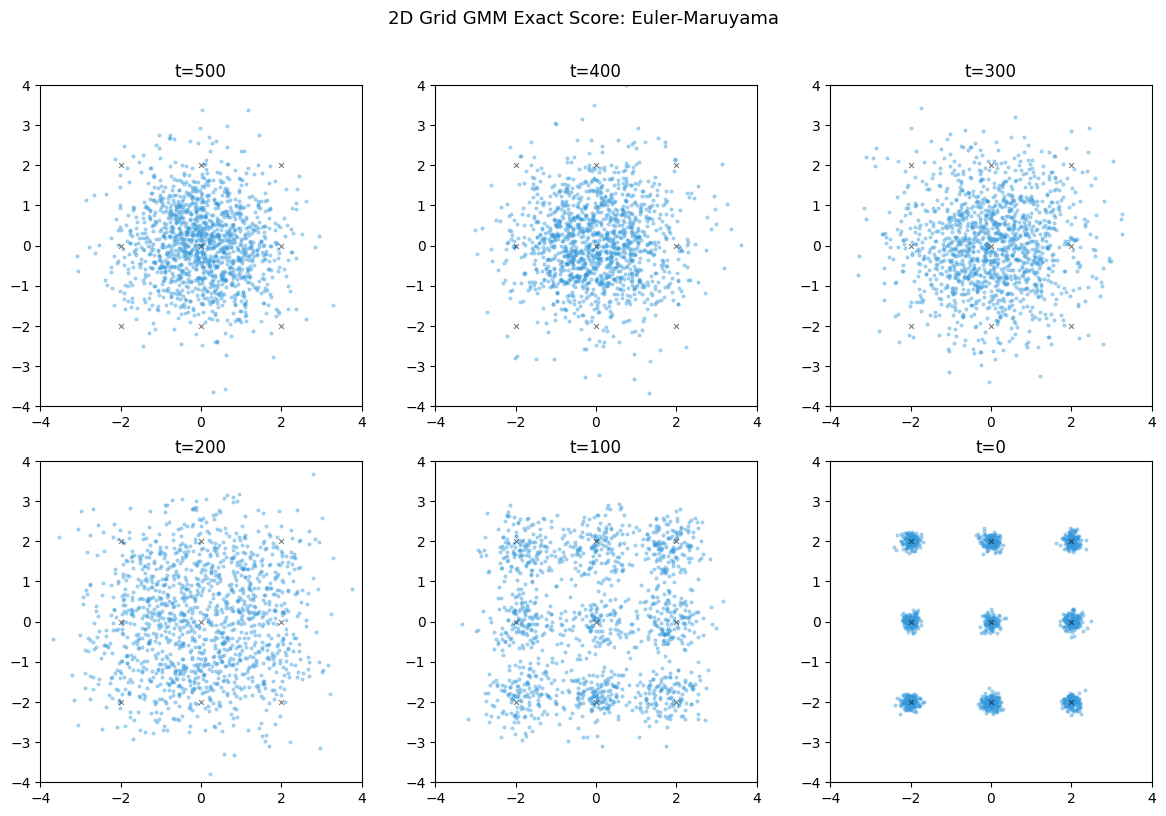

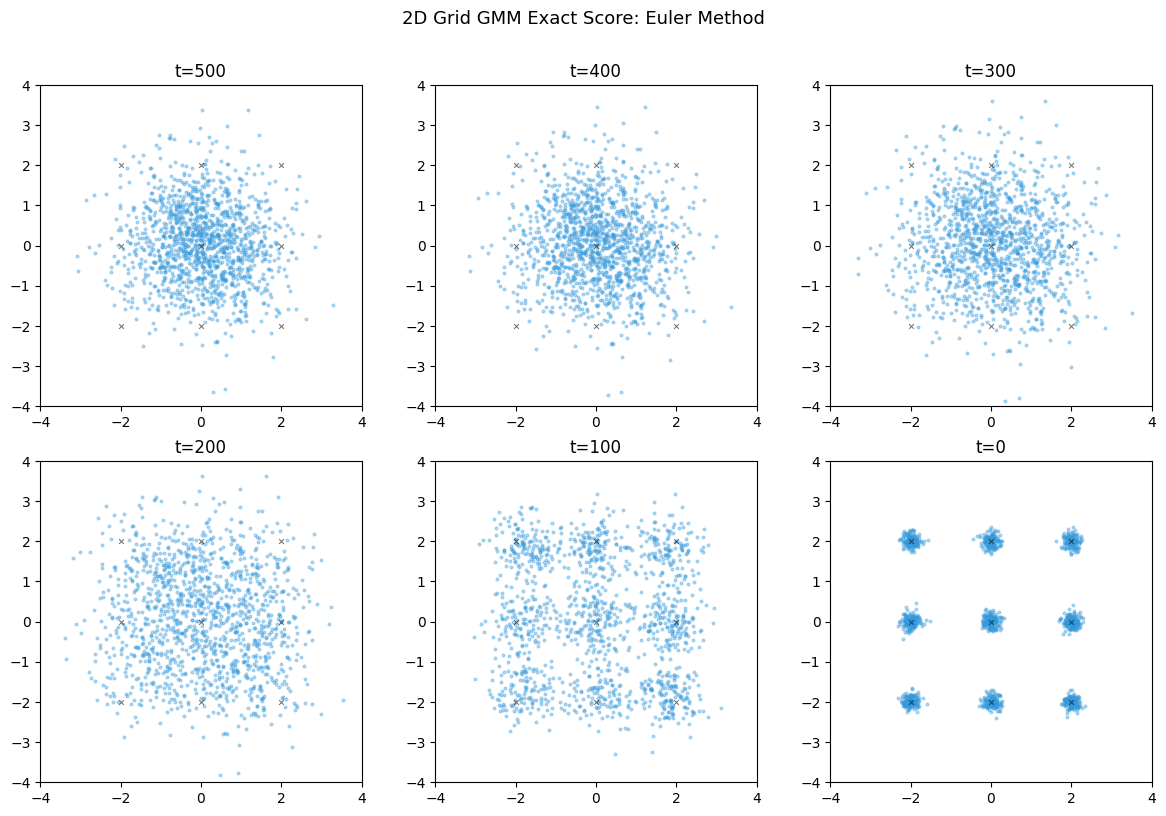

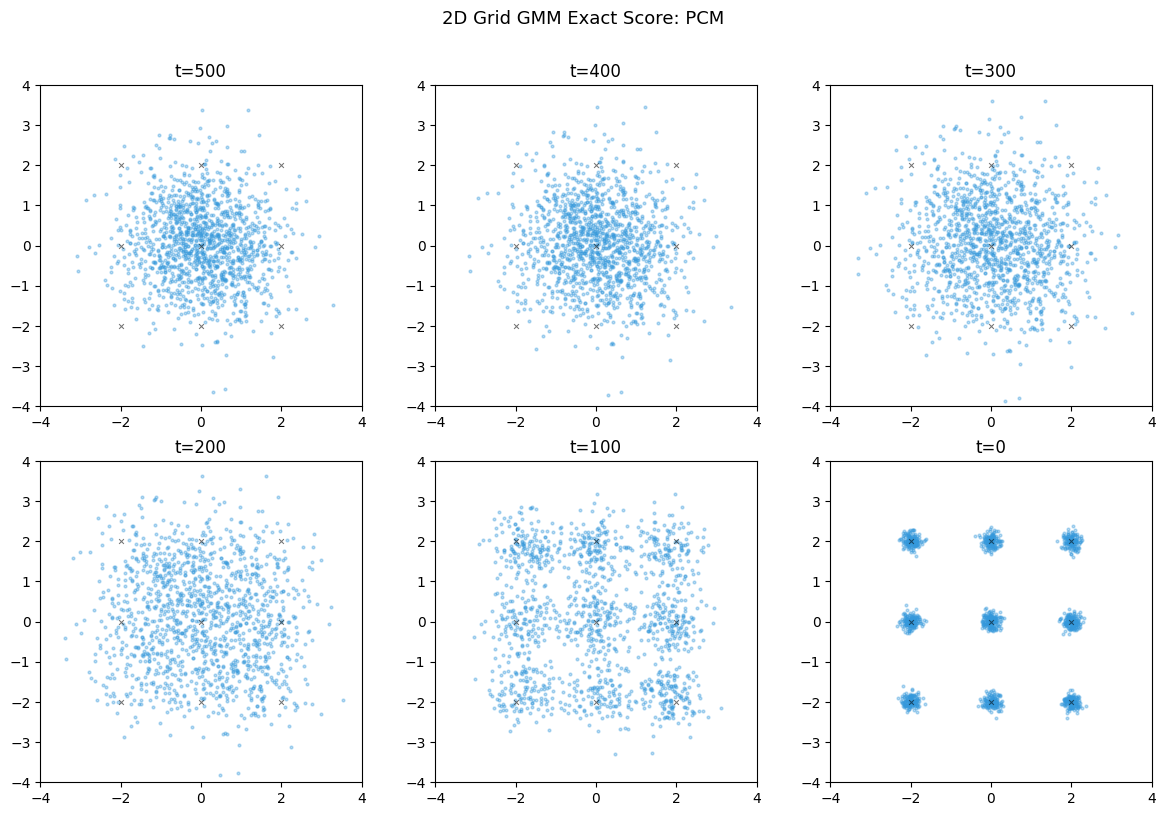

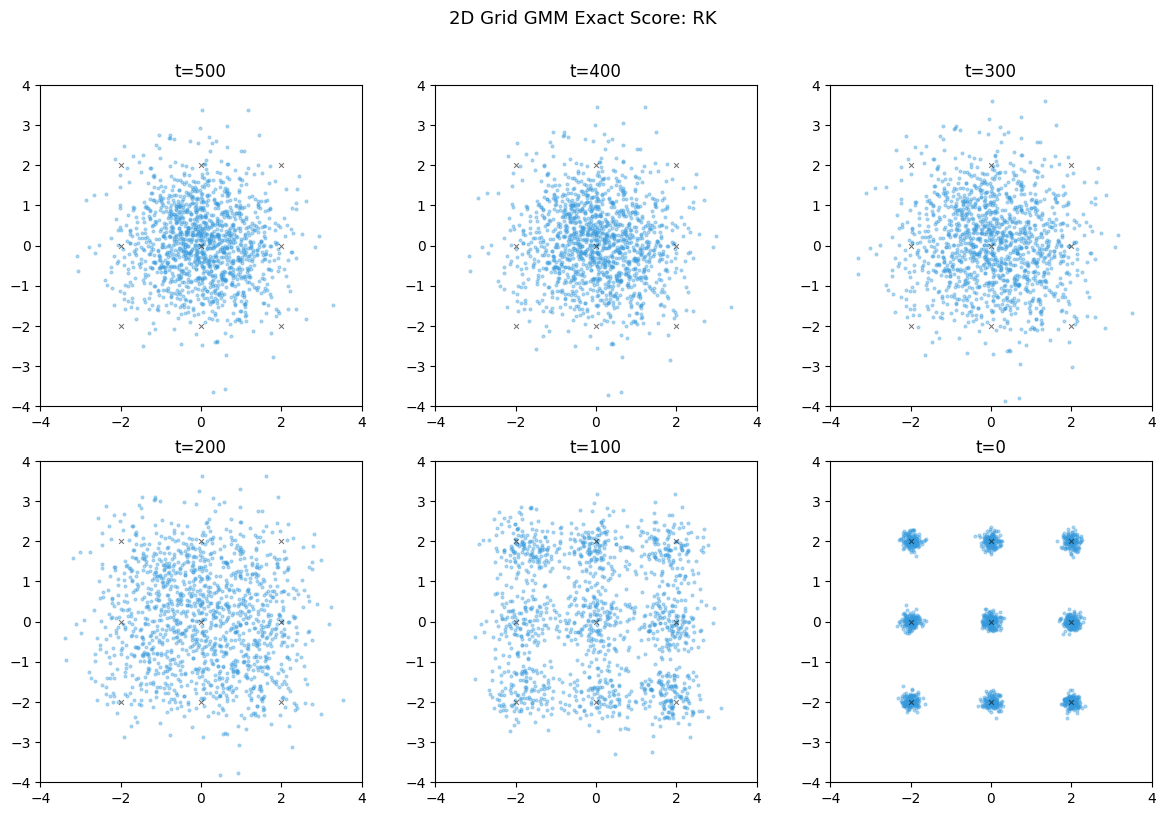

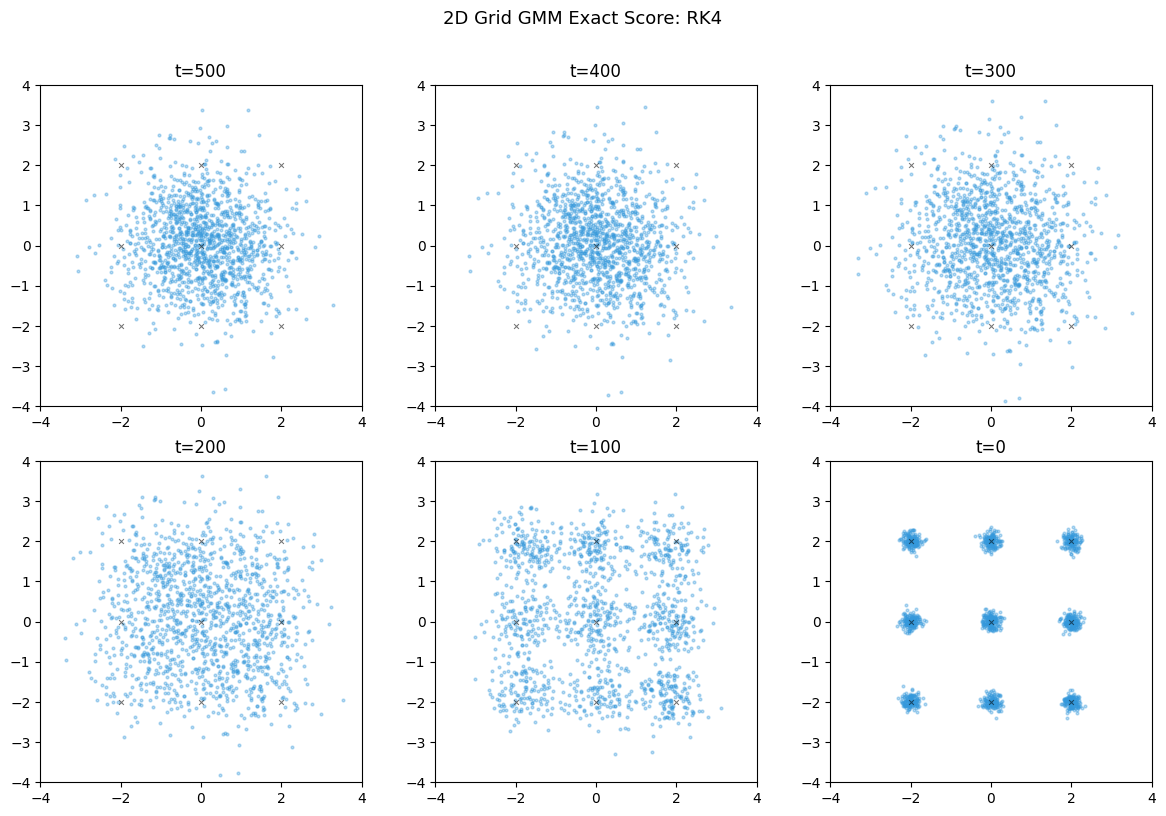

In [11]:
grid_trajs = run_reverse_for_dataset("grid")


## Two Moons: GMM Exact Score + EM/ODE Solvers

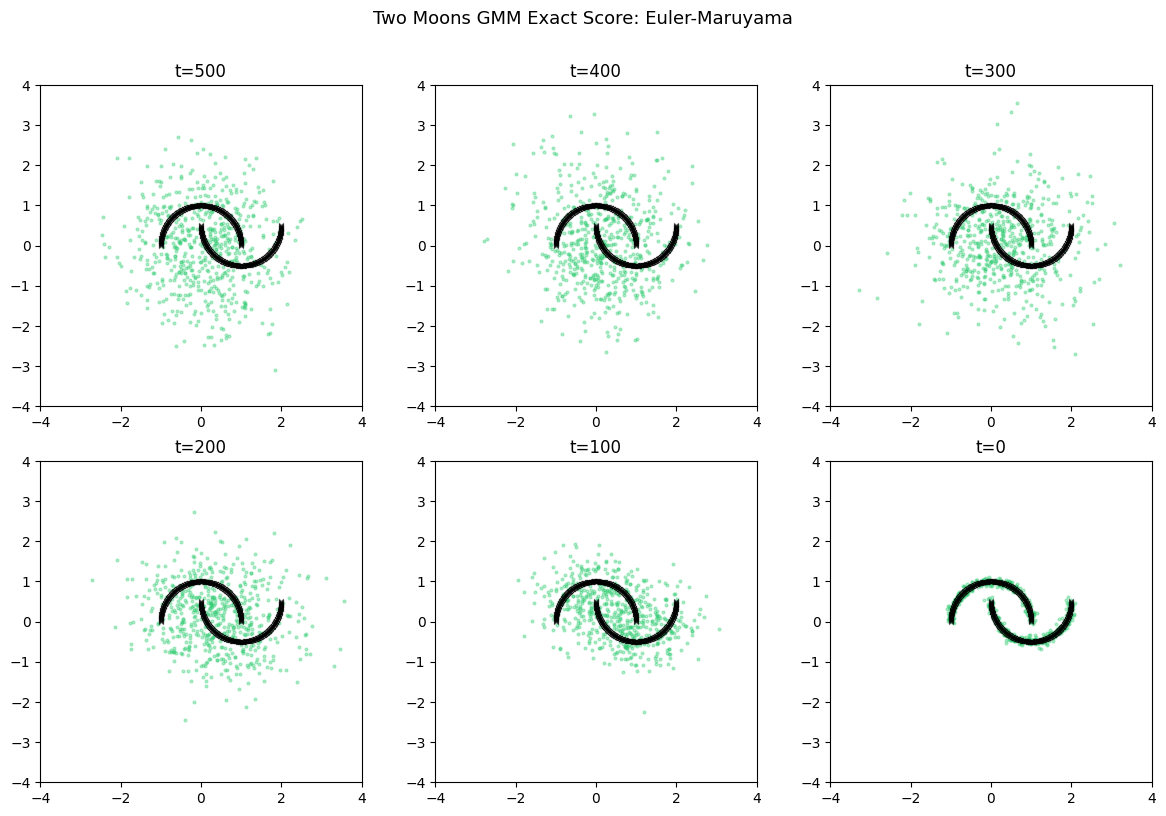

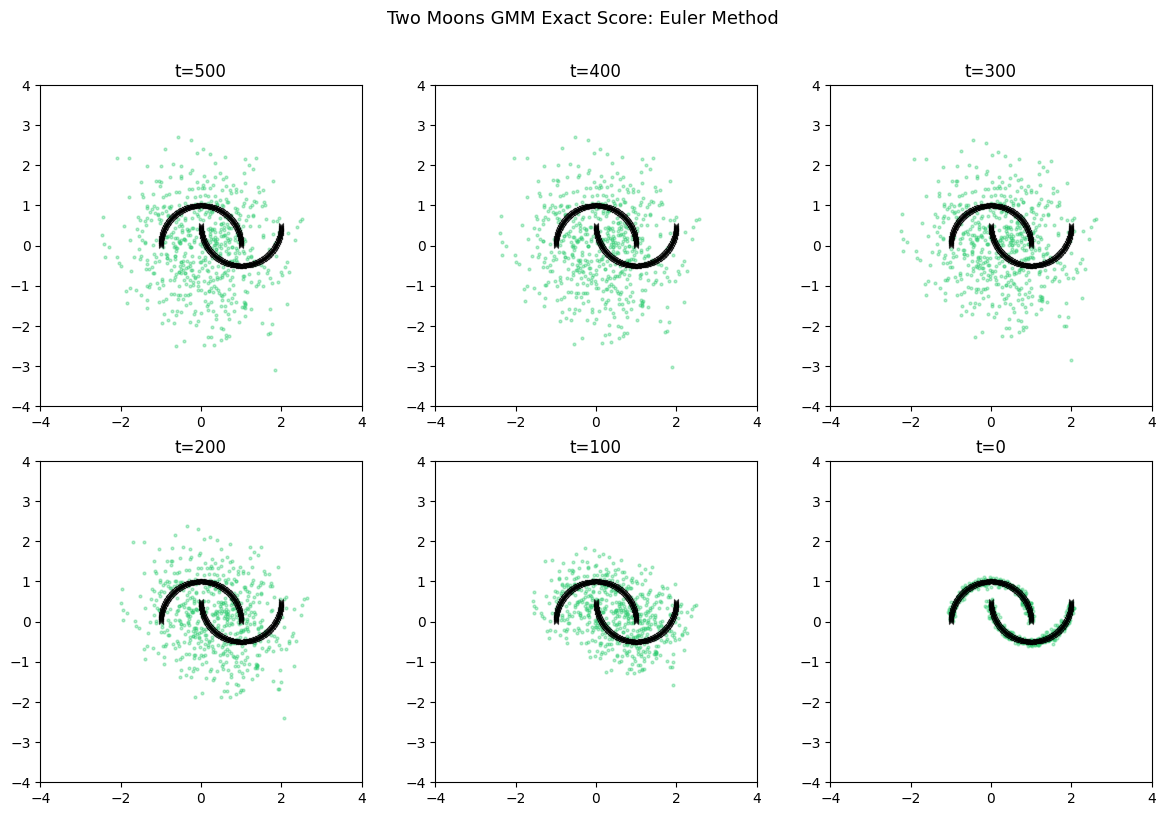

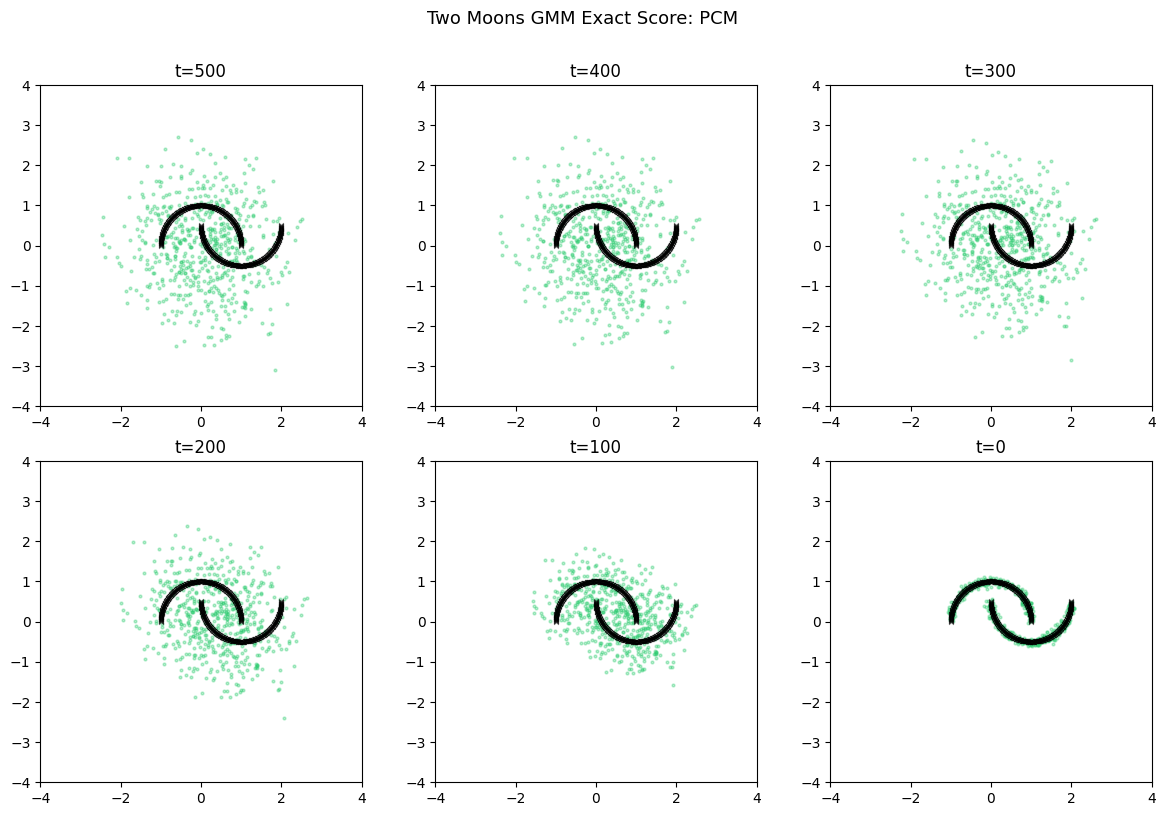

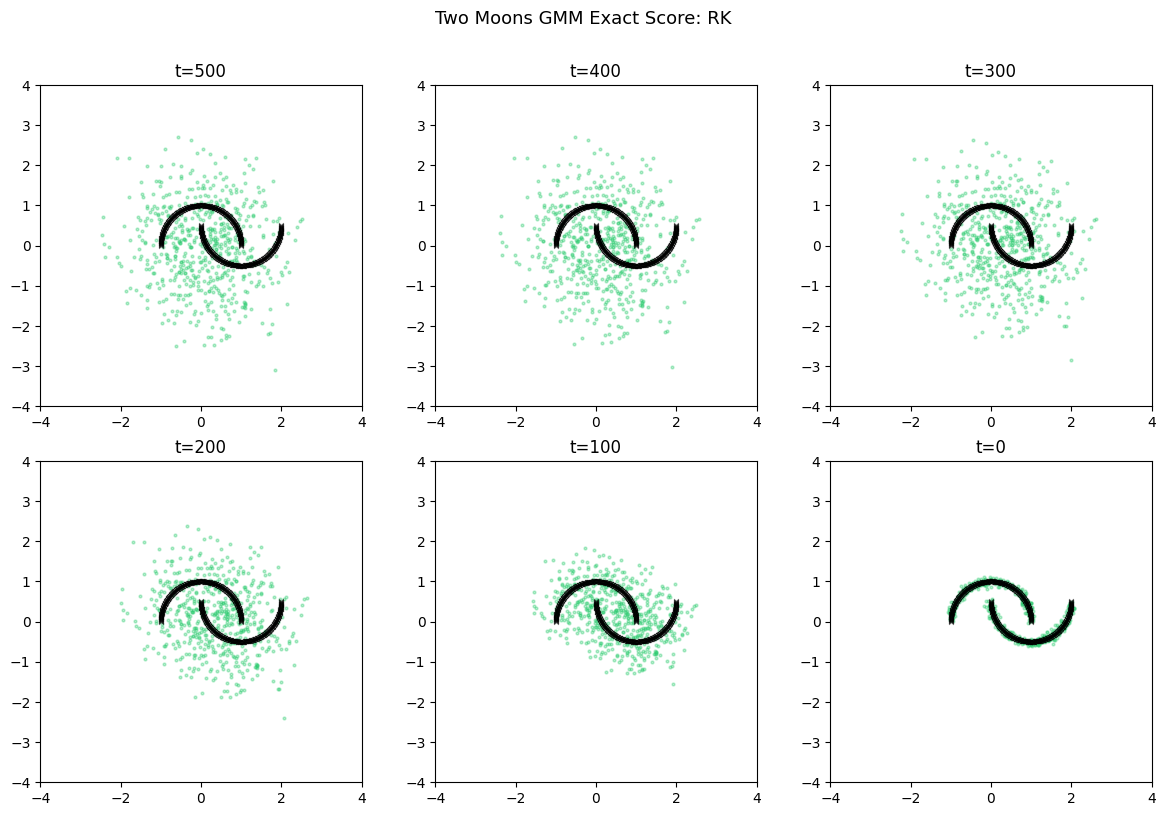

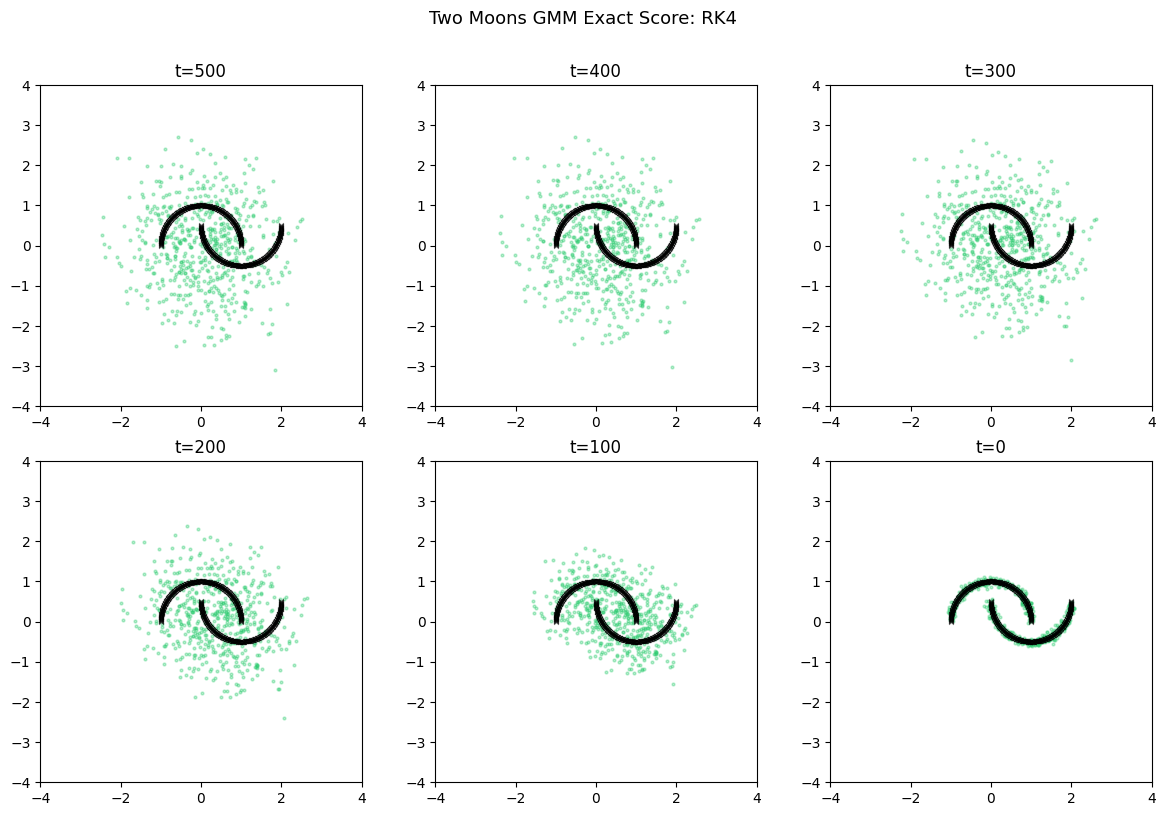

In [12]:
moons_trajs = run_reverse_for_dataset("moons")


## 최종 복원 결과 비교

`t=0`에서 각 solver의 결과만 한 화면에 모아 비교합니다. 검은 `x`는 각 toydata의 GMM 중심점입니다.


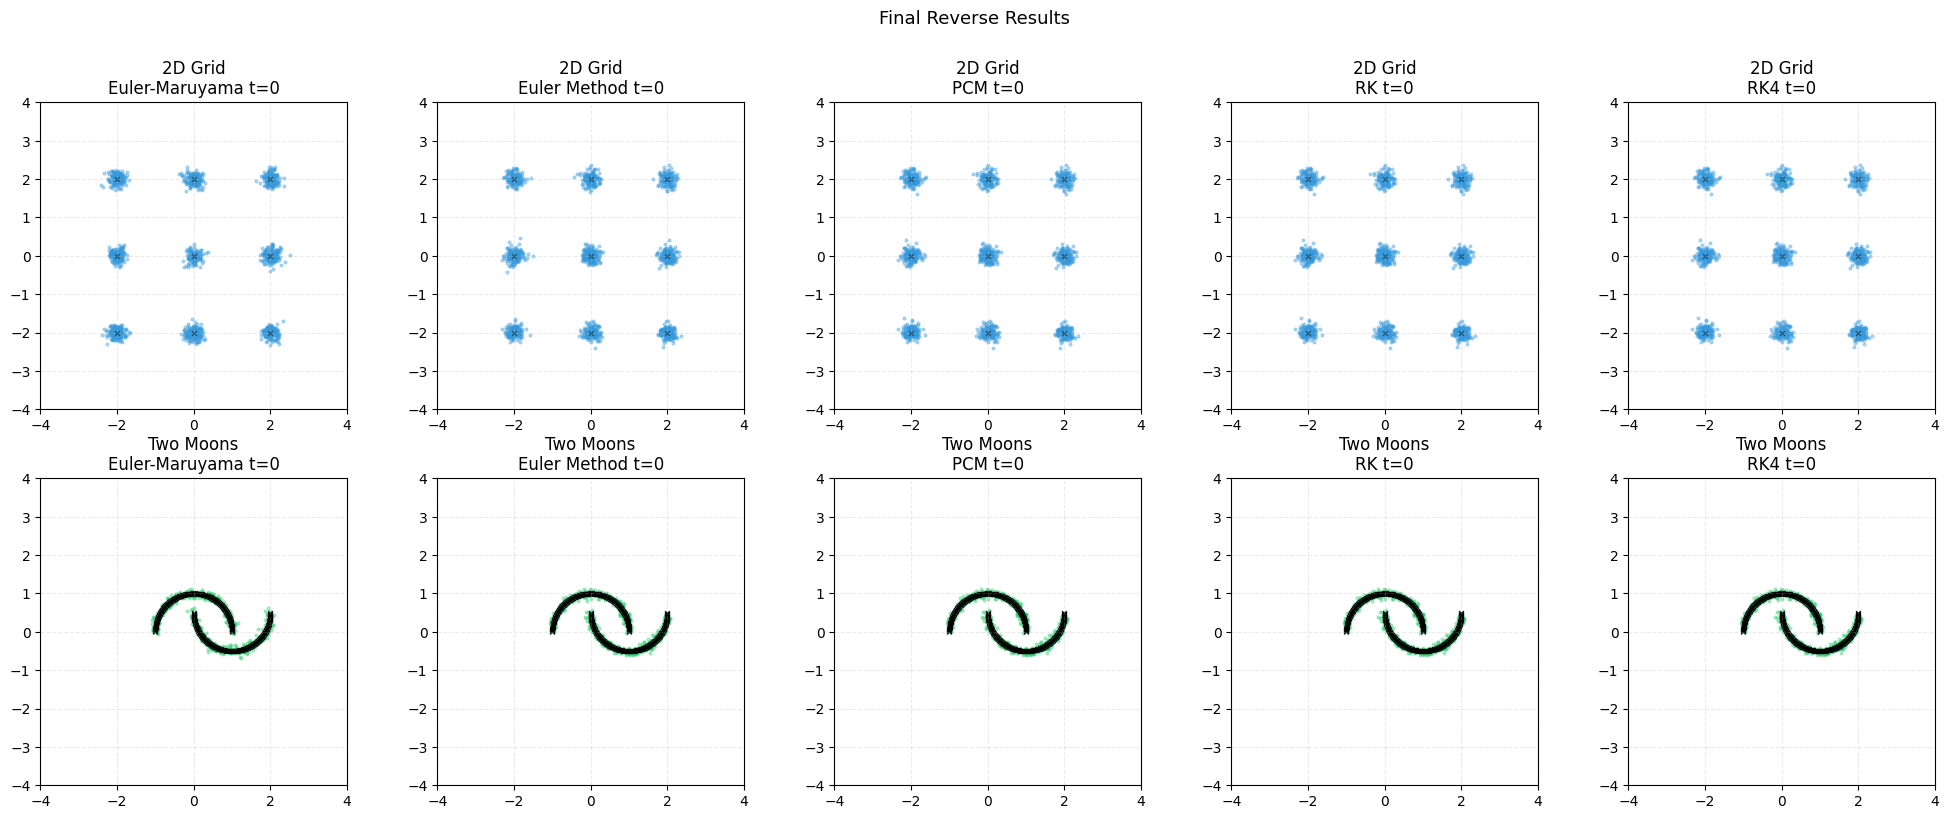

In [13]:
def plot_final_comparison(all_trajs):
    solver_names = list(next(iter(all_trajs.values())).keys())
    fig, axes = plt.subplots(len(all_trajs), len(solver_names), figsize=(4 * len(solver_names), 4 * len(all_trajs)))
    axes = np.atleast_2d(axes)

    for row, (name, trajs) in enumerate(all_trajs.items()):
        cfg = DATASET_CONFIGS[name]
        means = cfg["means"]
        for col, solver_name in enumerate(solver_names):
            ax = axes[row, col]
            pts = trajs[solver_name][0]
            ax.scatter(*pts.T, s=4, alpha=0.35, c=cfg["color"])
            ax.scatter(*means.T, s=12, c="black", marker="x", linewidths=0.75, alpha=0.55)
            ax.set_xlim(-4, 4)
            ax.set_ylim(-4, 4)
            ax.set_aspect("equal")
            ax.grid(True, linestyle="--", alpha=0.25)
            ax.set_title(f"{cfg['title']}\n{solver_name} t=0")

    fig.suptitle("Final Reverse Results", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()


all_trajs = {
    "grid": grid_trajs,
    "moons": moons_trajs,
}
plot_final_comparison(all_trajs)


## Debugging

각 데이터셋과 solver에 대해 스텝별 score 크기와 drift 크기를 확인합니다.


In [14]:
# ── 디버깅 1: 스텝별 x 통계 ──────────────────────────────────────────────────
debug_steps = [500, 400, 300, 200, 100, 50, 10, 1, 0]


def print_debug_stats(dataset_name, solver_name, traj):
    score_fn = score_fns[dataset_name]

    print()
    print(f"{DATASET_CONFIGS[dataset_name]['title']} - {solver_name}")
    print(f"{'t':>5} | {'N':>5} | {'mean_x':>8} | {'std_x':>8} | {'score_mag':>10} | {'drift_mag':>10}")
    print("-" * 65)
    for t in debug_steps:
        pts = traj[t]
        b = beta_fn(t)
        s = score_fn(pts, t)
        drift = b * (-0.5 * pts - s)
        print(
            f"{t:>5} | {len(pts):>5} | {pts.mean():>8.4f} | {pts.std():>8.4f} | "
            f"{np.linalg.norm(s, axis=1).mean():>10.4f} | {np.linalg.norm(drift, axis=1).mean():>10.4f}"
        )


for dataset_name, trajs in all_trajs.items():
    for solver_name, traj in trajs.items():
        print_debug_stats(dataset_name, solver_name, traj)



2D Grid - Euler-Maruyama
    t |     N |   mean_x |    std_x |  score_mag |  drift_mag
-----------------------------------------------------------------
  500 |  1350 |   0.0424 |   0.9872 |     1.2237 |     0.0121
  400 |  1350 |   0.0371 |   1.0354 |     1.2133 |     0.0091
  300 |  1350 |   0.0133 |   1.1316 |     1.0844 |     0.0046
  200 |  1350 |   0.0243 |   1.3565 |     0.9236 |     0.0035
  100 |  1350 |   0.0233 |   1.5671 |     2.2742 |     0.0088
   50 |  1350 |   0.0288 |   1.6376 |     4.7055 |     0.0097
   10 |  1350 |   0.0215 |   1.6605 |     9.3583 |     0.0046
    1 |  1350 |   0.0218 |   1.6640 |    10.2336 |     0.0014
    0 |  1350 |   0.0221 |   1.6642 |    10.2883 |     0.0010

2D Grid - Euler Method
    t |     N |   mean_x |    std_x |  score_mag |  drift_mag
-----------------------------------------------------------------
  500 |  1350 |   0.0424 |   0.9872 |     1.2237 |     0.0121
  400 |  1350 |   0.0435 |   1.0139 |     1.1895 |     0.0089
  300 |  135

In [15]:
# ── 디버깅 2: t=1 근처에서 score vs noise 크기 비교 ──────────────────────────
def print_near_zero_score_stats(dataset_name, traj):
    cfg = DATASET_CONFIGS[dataset_name]
    score_fn = score_fns[dataset_name]

    print()
    print(f"{cfg['title']} - Euler-Maruyama near t=0")
    print("t  | var_t    | score_mag | noise_std | drift_mag")
    print("-" * 55)
    for t in [10, 5, 2, 1, 0]:
        ab = alpha_bar_fn(t)
        s2 = sigma2_fn(t)
        var_t = ab * cfg["std"] ** 2 + s2
        b = beta_fn(t)

        pts = traj[t]
        s = score_fn(pts, t)
        drift = b * (-0.5 * pts - s)

        print(
            f"{t:>2} | {var_t:.6f} | {np.linalg.norm(s, axis=1).mean():>9.4f} | "
            f"{np.sqrt(b):>9.4f} | {np.linalg.norm(drift, axis=1).mean():>9.4f}"
        )


print_near_zero_score_stats("grid", grid_trajs["Euler-Maruyama"])
print_near_zero_score_stats("moons", moons_trajs["Euler-Maruyama"])



2D Grid - Euler-Maruyama near t=0
t  | var_t    | score_mag | noise_std | drift_mag
-------------------------------------------------------
10 | 0.017346 |    9.3583 |    0.0223 |    0.0046
 5 | 0.015384 |    9.8944 |    0.0173 |    0.0030
 2 | 0.014676 |   10.1597 |    0.0134 |    0.0018
 1 | 0.014518 |   10.2336 |    0.0118 |    0.0014
 0 | 0.014400 |   10.2883 |    0.0100 |    0.0010

Two Moons - Euler-Maruyama near t=0
t  | var_t    | score_mag | noise_std | drift_mag
-------------------------------------------------------
10 | 0.006579 |   10.1723 |    0.0223 |    0.0051
 5 | 0.004594 |   12.3320 |    0.0173 |    0.0037
 2 | 0.003879 |   13.5987 |    0.0134 |    0.0024
 1 | 0.003720 |   13.8531 |    0.0118 |    0.0019
 0 | 0.003600 |   14.0706 |    0.0100 |    0.0014


## Score Field 시각화

각 toydata의 score function이 공간의 각 위치에서 어느 방향을 가리키는지 quiver plot으로 확인합니다.


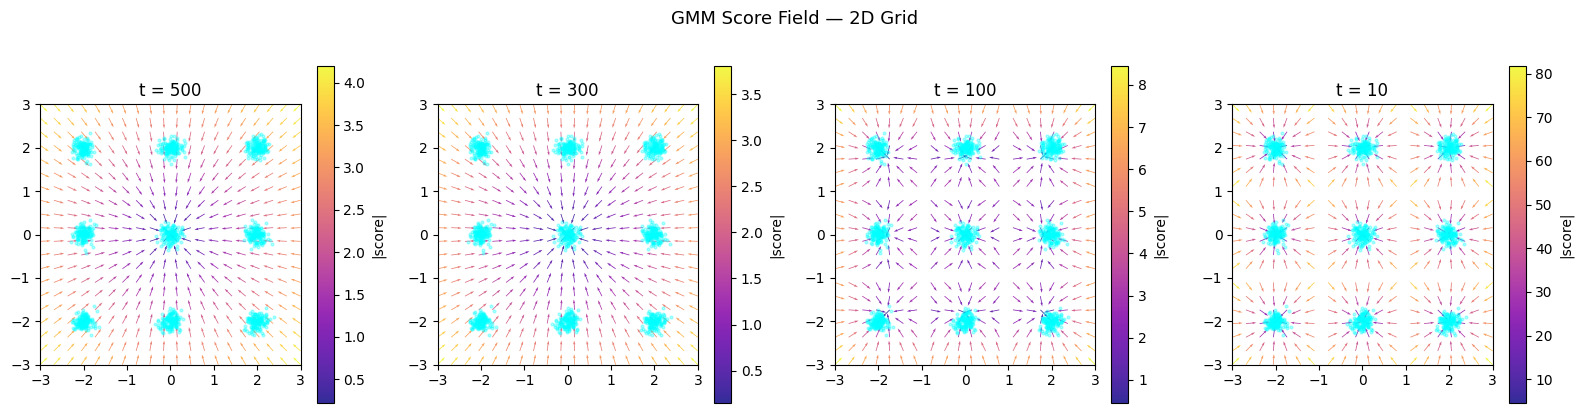

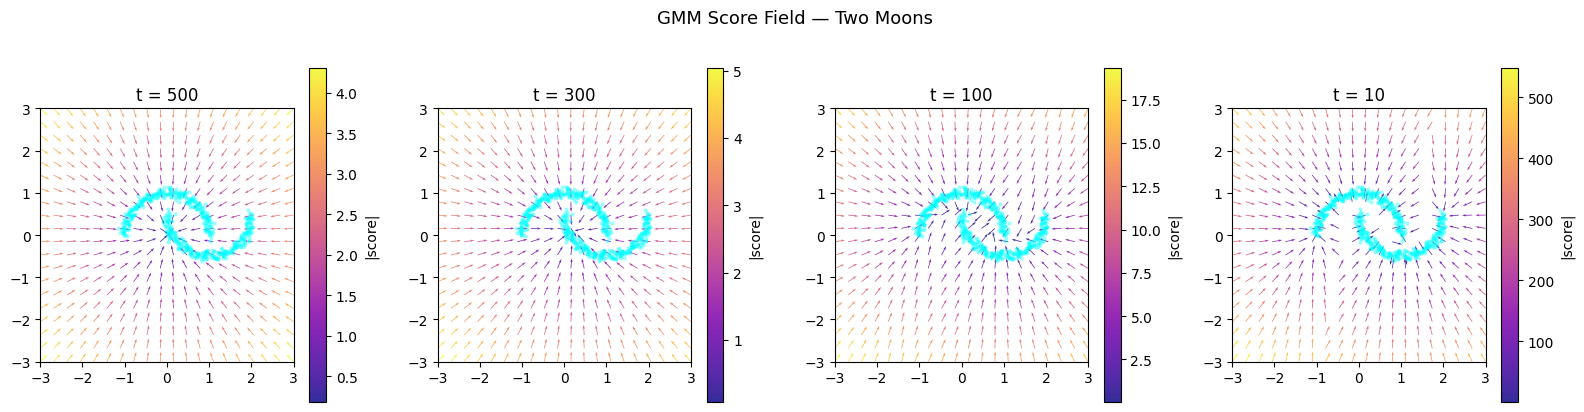

In [16]:
def plot_score_field(score_fn, t_list, n=20, data_pts=None, title="Score Field"):
    """격자 위에서 score 벡터 필드를 quiver로 시각화."""
    fig, axes = plt.subplots(1, len(t_list), figsize=(4 * len(t_list), 4))
    if len(t_list) == 1:
        axes = [axes]

    gx = np.linspace(-3, 3, n)
    gy = np.linspace(-3, 3, n)
    XX, YY = np.meshgrid(gx, gy)
    grid = np.stack([XX.ravel(), YY.ravel()], axis=1)  # (n*n, 2)

    for ax, t in zip(axes, t_list):
        s = score_fn(grid, t)
        mag = np.sqrt((s**2).sum(axis=1, keepdims=True))
        s_norm = s / (mag + 1e-8)

        q = ax.quiver(
            XX, YY,
            s_norm[:, 0].reshape(n, n),
            s_norm[:, 1].reshape(n, n),
            mag.reshape(n, n),
            cmap="plasma", scale=25, alpha=0.85,
        )
        plt.colorbar(q, ax=ax, label="|score|")

        if data_pts is not None:
            ax.scatter(*data_pts.T, s=4, alpha=0.3, c="cyan", zorder=3)

        ax.set_xlim(-3, 3)
        ax.set_ylim(-3, 3)
        ax.set_aspect("equal")
        ax.set_title(f"t = {t}")

    fig.suptitle(title, fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()


# 여러 시간대에서 각 toydata score 시각화
t_vis = [500, 300, 100, 10]
plot_score_field(
    grid_score, t_vis,
    data_pts=datasets["grid"],
    title="GMM Score Field — 2D Grid"
)
plot_score_field(
    moons_score, t_vis,
    data_pts=datasets["moons"],
    title="GMM Score Field — Two Moons"
)
